In [ ]:
# Install required packages for this notebook
%pip install scipy numpy pandas matplotlib ipykernel

In [78]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = r'1. BatteryAgingARC-FY08Q4\B0007.mat'
mat = scipy.io.loadmat(file_path)

# Extract Battery Info for plots
path_parts = file_path.replace('/', '\\').split('\\')
folder_name = path_parts[-2] if len(path_parts) >= 2 else ""
if '. ' in folder_name:
    folder_name = folder_name.split('. ', 1)[1]
battery_name = path_parts[-1].replace('.mat', '')
battery_title = f"{folder_name} - {battery_name}" if folder_name else battery_name


--- LIFECYCLE SUMMARY (Total Paired Cycles: 167) ---
 Cycle  Charge_In  Discharge_Out  Cum_Charge  Cum_Discharge
     1   0.806667       1.891052    0.806667       1.891052
    84   1.632276       1.610866  148.874412     149.938300
   167   1.446889       1.432455  275.316318     274.559981

Total Lifetime Capacity Processed: 274.56 Ah
Average Coulombic Efficiency: 131.74%
--- CLEANED LIFECYCLE SUMMARY (Total Valid Cycles: 160) ---
 Cycle  Charge_In  Discharge_Out  Efficiency
     1   1.920984       1.880634   97.899516
    81   1.620871       1.595923   98.460851
   160   1.446889       1.432455   99.002452

Average Coulombic Efficiency: 98.54%
Total Outliers Removed: 7


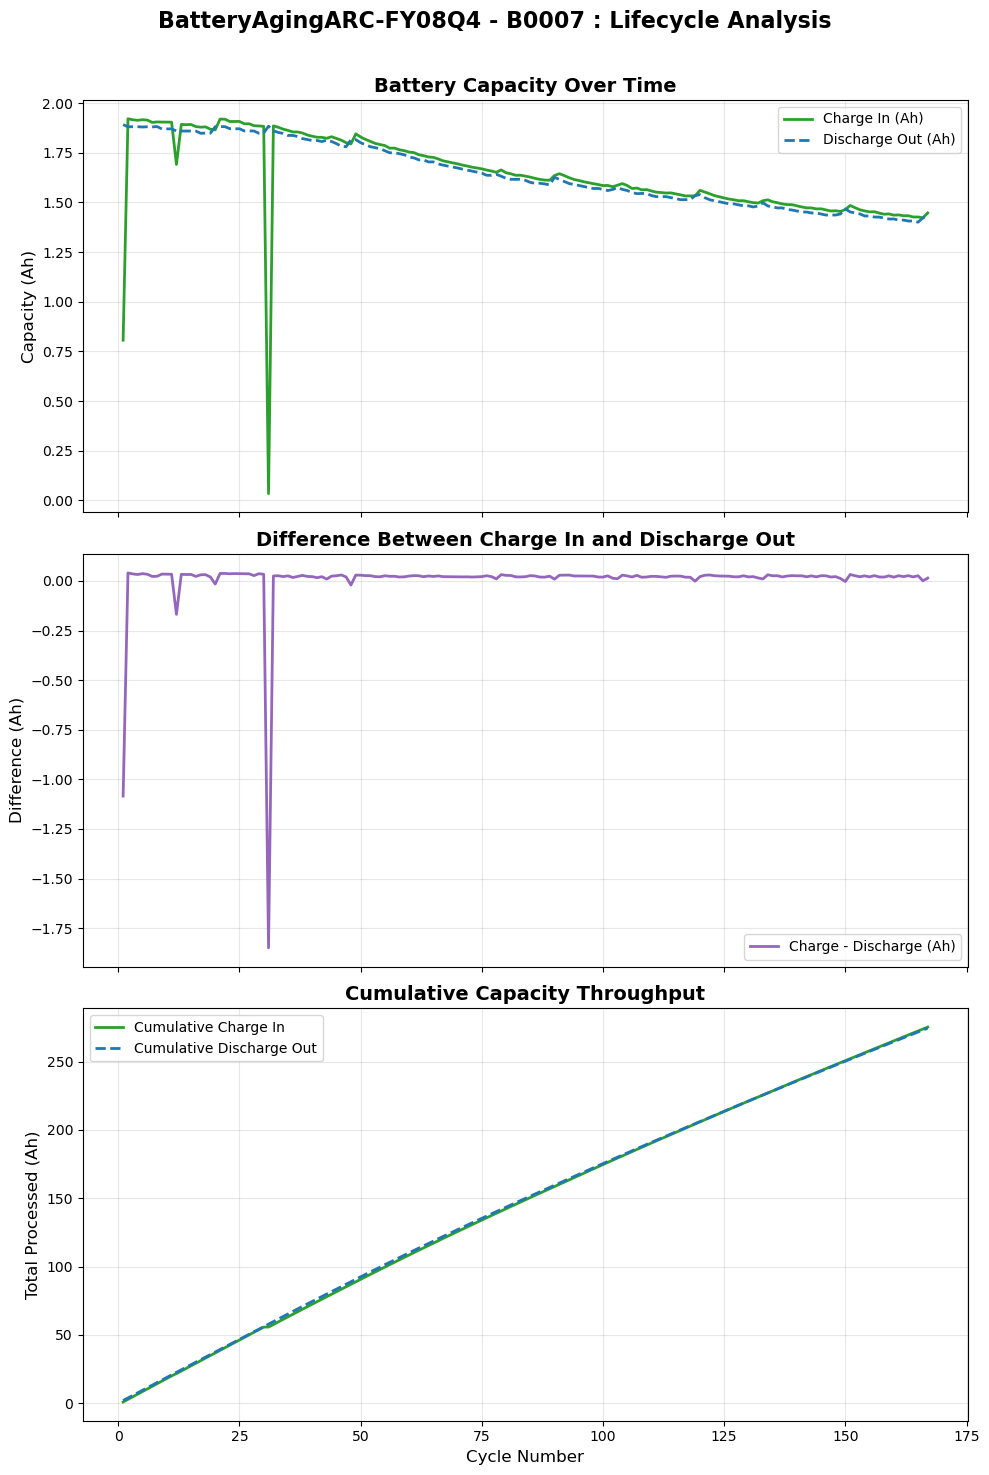

In [79]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming mat and battery_title are already defined in your environment
data_key = [k for k in mat.keys() if not k.startswith('__')][0]
cycles = mat[data_key][0, 0]['cycle'][0]

results = []
current_charge_cap = None
paired_cycle_count = 1

# Cumulative counters
total_charge_ah = 0.0
total_discharge_ah = 0.0

for cycle in cycles:
    c_type = cycle['type'][0]
    data = cycle['data'][0, 0]

    if c_type == 'charge':
        time = data['Time'][0]
        current = data['Current_measured'][0]
        
        # --- PHYSICAL CONSTRAINT: I > 0 ---
        pos_idx = np.where(current > 0)[0]
        if len(pos_idx) > 0:
            start_idx = pos_idx[0]
            end_idx = pos_idx[-1]
            time_trunc = time[start_idx:end_idx + 1]
            current_trunc = current[start_idx:end_idx + 1]
            
            dt = np.diff(time_trunc)
            avg_current = (current_trunc[:-1] + current_trunc[1:]) / 2
            current_charge_cap = np.sum(avg_current * dt) / 3600
        else:
            current_charge_cap = 0.0

    elif c_type == 'discharge':
        if current_charge_cap is not None:
            time = data['Time'][0]
            current = data['Current_measured'][0]
            voltage = data['Voltage_measured'][0]

            # --- PHYSICAL CONSTRAINT: 2.7V Cutoff ---
            cutoff_indices = np.where(voltage <= 2.7)[0]
            cutoff_idx = cutoff_indices[0] if len(cutoff_indices) > 0 else len(voltage) - 1

            # --- PHYSICAL CONSTRAINT: I <= 0 ---
            # Start discharge when current first becomes negative
            neg_indices = np.where(current[:cutoff_idx + 1] <= 0)[0]
            
            if len(neg_indices) == 0:
                discharge_cap = 0.0
            else:
                start_dis_idx = neg_indices[0]
                time_trunc = time[start_dis_idx:cutoff_idx + 1]
                current_trunc = current[start_dis_idx:cutoff_idx + 1]
                
                if len(time_trunc) < 2:
                    discharge_cap = 0.0
                else:
                    dt = np.diff(time_trunc)
                    avg_current = (np.abs(current_trunc[:-1]) + np.abs(current_trunc[1:])) / 2
                    discharge_cap = np.sum(avg_current * dt) / 3600

            # Calculate efficiency, handling zero-division for aborted charge cycles
            efficiency = (discharge_cap / current_charge_cap) * 100 if current_charge_cap > 0 else np.nan

            total_charge_ah += current_charge_cap
            total_discharge_ah += discharge_cap

            results.append({
                'Cycle': paired_cycle_count,
                'Charge_In': current_charge_cap,
                'Discharge_Out': discharge_cap,
                'Efficiency': efficiency,
                'Cum_Charge': total_charge_ah,
                'Cum_Discharge': total_discharge_ah,
                'difference': current_charge_cap - discharge_cap
            })
            paired_cycle_count += 1
            current_charge_cap = None # Reset for next pair

df = pd.DataFrame(results)

# After your df = pd.DataFrame(results) line:
# df = df.iloc[1:].copy() # Remove the first row (Cycle 1)
# df['Cycle'] = range(1, len(df) + 1) # Optional: Reset cycle numbers to start from 1

# Dynamic summary
if len(df) > 0:
    first_idx = 0
    mid_idx = len(df) // 2
    last_idx = len(df) - 1
    valid_eff = df['Efficiency'].replace([np.inf, -np.inf], np.nan).dropna()

    print(f"--- LIFECYCLE SUMMARY (Total Paired Cycles: {len(df)}) ---")
    print(df[['Cycle', 'Charge_In', 'Discharge_Out', 'Cum_Charge', 'Cum_Discharge']].iloc[[first_idx, mid_idx, last_idx]].to_string(index=False))
    print(f"\nTotal Lifetime Capacity Processed: {df['Cum_Discharge'].iloc[-1]:.2f} Ah")
    if len(valid_eff) > 0:
        print(f"Average Coulombic Efficiency: {valid_eff.mean():.2f}%")
else:
    print('No valid paired cycles found.')

# 2. APPLY PHYSICAL MASK: Remove all cycles with non-physical efficiency
# High-quality batteries like these should be between 90% and 100%
df_clean = df[(df['Efficiency'] > 70) & (df['Efficiency'] <= 100)].copy()

# 3. RECALCULATE CUMULATIVE DATA (Crucial for MEng Accuracy)
# Now that we've removed the "junk" cycles, we reset the throughput counters
df_clean['Cycle'] = range(1, len(df_clean) + 1)
df_clean['Cum_Charge'] = df_clean['Charge_In'].cumsum()
df_clean['Cum_Discharge'] = df_clean['Discharge_Out'].cumsum()

# 4. PRODUCING CLEAN SUMMARY
if len(df_clean) > 0:
    print(f"--- CLEANED LIFECYCLE SUMMARY (Total Valid Cycles: {len(df_clean)}) ---")
    print(df_clean[['Cycle', 'Charge_In', 'Discharge_Out', 'Efficiency']].iloc[[0, len(df_clean)//2, -1]].to_string(index=False))
    print(f"\nAverage Coulombic Efficiency: {df_clean['Efficiency'].mean():.2f}%")
    print(f"Total Outliers Removed: {len(df) - len(df_clean)}")

# df = df_clean  # Use the cleaned DataFrame for plotting
# Plotting
if len(df) > 0:
    # Fallback title if battery_title isn't defined in your environment
    battery_title = "Battery" if 'battery_title' not in locals() else battery_title
    
    fig, axs = plt.subplots(3, 1, figsize=(10, 15), sharex=True)
    fig.suptitle(f"{battery_title} : Lifecycle Analysis", fontsize=16, fontweight='bold', y=0.98)

    # Plot 1: Capacity In vs Out
    axs[0].plot(df['Cycle'], df['Charge_In'], label='Charge In (Ah)', color='tab:green', linewidth=2)
    axs[0].plot(df['Cycle'], df['Discharge_Out'], label='Discharge Out (Ah)', color='tab:blue', linestyle='--', linewidth=2)
    axs[0].set_title(f'Battery Capacity Over Time', fontsize=14, fontweight='bold')
    axs[0].set_ylabel('Capacity (Ah)', fontsize=12)
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)

    # plot 2: difference between charge in and discharge cumulatively
    axs[1].plot(df['Cycle'], df['difference'], label='Charge - Discharge (Ah)', color='tab:purple', linewidth=2)
    axs[1].set_title(f'Difference Between Charge In and Discharge Out', fontsize=14, fontweight='bold')
    axs[1].set_ylabel('Difference (Ah)', fontsize=12)
    axs[1].legend()
    axs[1].grid(True, alpha=0.3)

    # Plot 3: Cumulative Capacity Throughput
    axs[2].plot(df['Cycle'], df['Cum_Charge'], label='Cumulative Charge In', color='tab:green', linewidth=2)
    axs[2].plot(df['Cycle'], df['Cum_Discharge'], label='Cumulative Discharge Out', color='tab:blue', linestyle='--', linewidth=2)
    axs[2].set_title(f'Cumulative Capacity Throughput', fontsize=14, fontweight='bold')
    axs[2].set_xlabel('Cycle Number', fontsize=12)
    axs[2].set_ylabel('Total Processed (Ah)', fontsize=12)
    axs[2].legend(loc='upper left')
    axs[2].grid(True, alpha=0.3)

    plt.tight_layout()
    fig.subplots_adjust(top=0.92)
    plt.show()

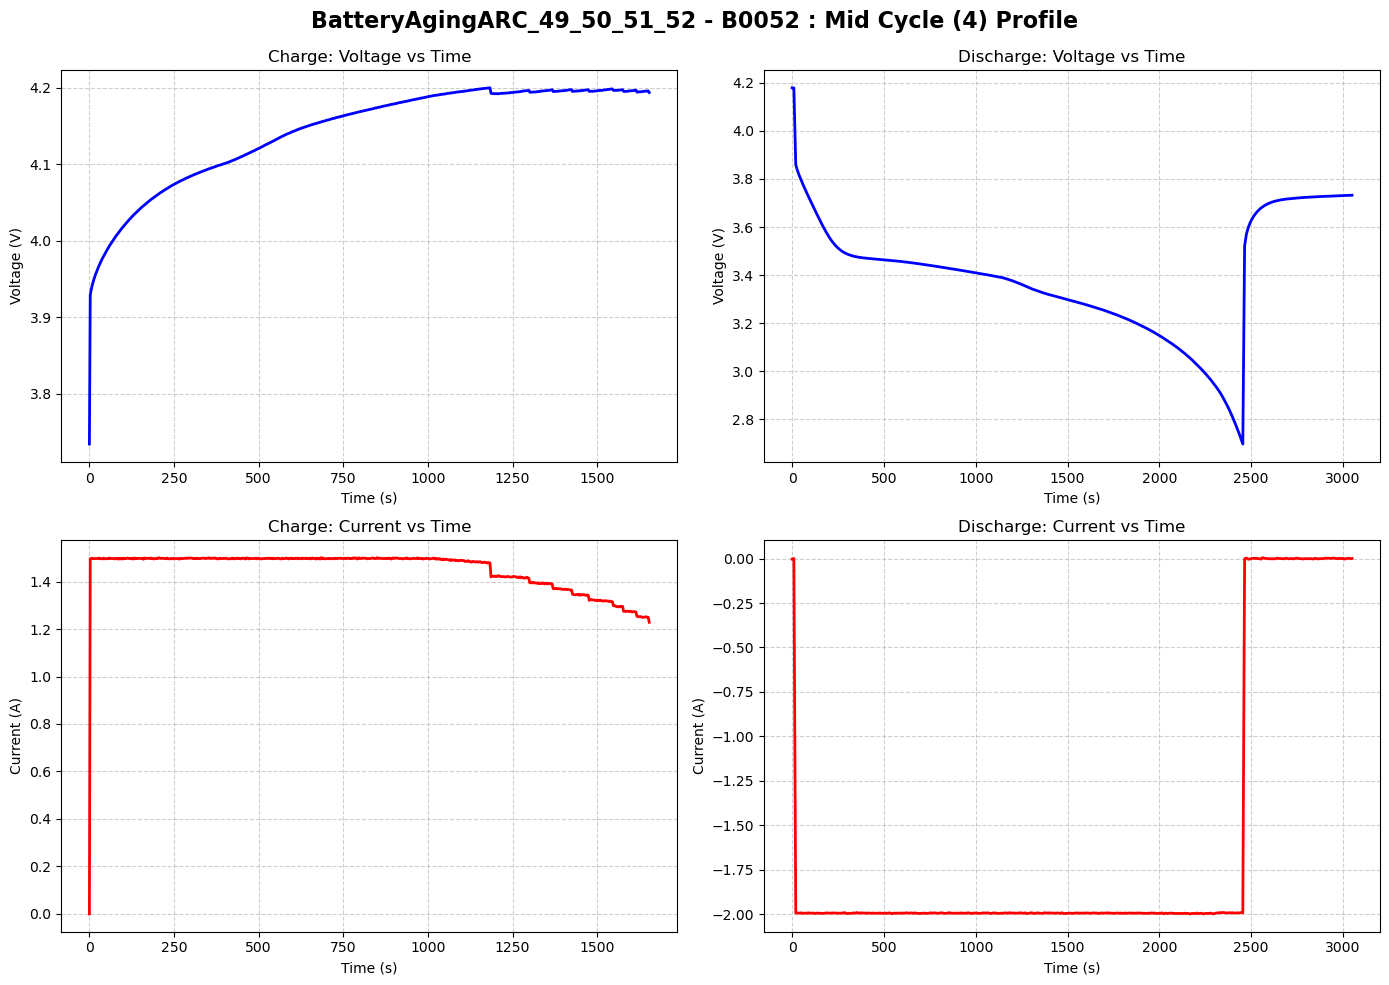

Successfully generated plot for BatteryAgingARC_49_50_51_52 - B0052 (Cycle 4).


In [77]:
try:
    
    # Get the battery ID key dynamically
    data_key = [k for k in mat.keys() if not k.startswith('__')][0]
    cycles = mat[data_key][0, 0]['cycle'][0]
    
    # Filter for charge and discharge cycles
    charge_cycles = [c for c in cycles if c['type'][0] == 'charge']
    discharge_cycles = [c for c in cycles if c['type'][0] == 'discharge']
    
    # Determine the mid cycle index
    mid_idx = len(discharge_cycles) // 2 
    mid_idx = 3
    
    if mid_idx < len(discharge_cycles) and mid_idx < len(charge_cycles):
        # Extract Charge Data
        c_data = charge_cycles[mid_idx]['data'][0, 0]
        c_time = c_data['Time'][0]
        c_voltage = c_data['Voltage_measured'][0]
        c_current = c_data['Current_measured'][0]
        
        # Extract Discharge Data
        d_data = discharge_cycles[mid_idx]['data'][0, 0]
        d_time = d_data['Time'][0]
        d_voltage = d_data['Voltage_measured'][0]
        d_current = d_data['Current_measured'][0]
        
        # Create a 2x2 plot for Voltage and Current (Charge & Discharge)
        fig, axs = plt.subplots(2, 2, figsize=(14, 10))
        
        # Add the overall title containing the battery name
        fig.suptitle(f"{battery_title} : Mid Cycle ({mid_idx + 1}) Profile", fontsize=16, fontweight='bold')
        
        # Charge Voltage
        axs[0, 0].plot(c_time, c_voltage, color='blue', linewidth=2)
        axs[0, 0].set_title("Charge: Voltage vs Time")
        axs[0, 0].set_xlabel("Time (s)")
        axs[0, 0].set_ylabel("Voltage (V)")
        axs[0, 0].grid(True, linestyle='--', alpha=0.6)
        
        # Charge Current
        axs[1, 0].plot(c_time, c_current, color='red', linewidth=2)
        axs[1, 0].set_title("Charge: Current vs Time")
        axs[1, 0].set_xlabel("Time (s)")
        axs[1, 0].set_ylabel("Current (A)")
        axs[1, 0].grid(True, linestyle='--', alpha=0.6)
        
        # Discharge Voltage
        axs[0, 1].plot(d_time, d_voltage, color='blue', linewidth=2)
        axs[0, 1].set_title("Discharge: Voltage vs Time")
        axs[0, 1].set_xlabel("Time (s)")
        axs[0, 1].set_ylabel("Voltage (V)")
        axs[0, 1].grid(True, linestyle='--', alpha=0.6)
        
        # Discharge Current
        axs[1, 1].plot(d_time, d_current, color='red', linewidth=2)
        axs[1, 1].set_title("Discharge: Current vs Time")
        axs[1, 1].set_xlabel("Time (s)")
        axs[1, 1].set_ylabel("Current (A)")
        axs[1, 1].grid(True, linestyle='--', alpha=0.6)
        
        plt.tight_layout()
        fig.subplots_adjust(top=0.92) # Add spacing for the suptitle
        plt.savefig(f'{battery_name}_mid_cycle_{mid_idx + 1}_plot.png')
        plt.show()
        print(f"Successfully generated plot for {battery_title} (Cycle {mid_idx + 1}).")
    else:
        print("Not enough charge/discharge cycles found.")

except Exception as e:
    print(f"Error: {e}")